In [1]:
import pandas as pd

# Technical Features
technical = pd.read_csv("silver_technical_features_v1.csv")

# Macro + Sentiment Features
advanced = pd.read_csv("silver_advanced_feature_engineering.csv")

In [2]:
technical["Date"] = pd.to_datetime(technical["Date"])
advanced["Date"] = pd.to_datetime(advanced["Date"])

In [3]:
advanced = advanced[
    ["Date"] +
    [
        col for col in advanced.columns
        if col not in technical.columns
    ]
]

In [4]:
full_data = technical.merge(
    advanced,
    on="Date",
    how="left"
)

print(full_data.shape)

print(full_data.columns.tolist())

(6504, 111)
['Date', 'Open', 'High', 'Low', 'Close', 'Adj_Close', 'Volume', 'VWAP', 'Returns_Pct', 'Log_Returns', 'Dollar_Change', 'Intraday_Range', 'Intraday_Range_Pct', 'SMA20', 'SMA50', 'SMA200', 'EMA12', 'EMA26', 'MACD', 'RSI', 'BB_Upper', 'BB_Lower', 'ATR', 'Lag_1', 'Lag_3', 'Lag_7', 'Lag_14', 'Rolling_Mean_7', 'Rolling_STD_7', 'Market_Regime', 'Momentum_5', 'Momentum_5_Pct', 'Momentum_10', 'Momentum_20', 'Trend_Strength', 'ATR_Norm', 'Vol_Norm', 'Risk_Score', 'Risk_Level', 'Stoch_K', 'Stoch_D', 'OBV', 'ADX', 'Ichimoku_A', 'Ichimoku_B', 'Fib_38', 'Fib_61', 'Lag_2', 'Lag_5', 'Lag_10', 'Lag_20', 'Lag_60', 'Rolling_STD_5', 'Rolling_STD_10', 'Rolling_STD_20', 'Rolling_STD_60', 'Parkinson_Vol', 'Silver_Price_USD', 'Gold_Price_USD', 'Silver_Gold_Ratio', 'Fed_Funds_Rate', 'US_10Y_Yield', 'Real_Interest_Rate', 'US_CPI_Index', 'US_CPI_YoY_Pct', 'DXY_Index', 'Crude_Oil_WTI', 'VIX_Index', 'US_M2_Supply_Trillions', 'India_Repo_Rate', 'USD_INR', 'Silver_Price_INR_Per_Kg', 'Global_PMI', 'US_Une

In [5]:
full_data = full_data.ffill()
full_data = full_data.bfill()

In [6]:
X = full_data.drop(
    columns=[
        "Date",
        "Close"
    ],
    errors="ignore"
)

y = full_data["Close"]

print("Features:", len(X.columns))
print(X.columns.tolist())

Features: 109
['Open', 'High', 'Low', 'Adj_Close', 'Volume', 'VWAP', 'Returns_Pct', 'Log_Returns', 'Dollar_Change', 'Intraday_Range', 'Intraday_Range_Pct', 'SMA20', 'SMA50', 'SMA200', 'EMA12', 'EMA26', 'MACD', 'RSI', 'BB_Upper', 'BB_Lower', 'ATR', 'Lag_1', 'Lag_3', 'Lag_7', 'Lag_14', 'Rolling_Mean_7', 'Rolling_STD_7', 'Market_Regime', 'Momentum_5', 'Momentum_5_Pct', 'Momentum_10', 'Momentum_20', 'Trend_Strength', 'ATR_Norm', 'Vol_Norm', 'Risk_Score', 'Risk_Level', 'Stoch_K', 'Stoch_D', 'OBV', 'ADX', 'Ichimoku_A', 'Ichimoku_B', 'Fib_38', 'Fib_61', 'Lag_2', 'Lag_5', 'Lag_10', 'Lag_20', 'Lag_60', 'Rolling_STD_5', 'Rolling_STD_10', 'Rolling_STD_20', 'Rolling_STD_60', 'Parkinson_Vol', 'Silver_Price_USD', 'Gold_Price_USD', 'Silver_Gold_Ratio', 'Fed_Funds_Rate', 'US_10Y_Yield', 'Real_Interest_Rate', 'US_CPI_Index', 'US_CPI_YoY_Pct', 'DXY_Index', 'Crude_Oil_WTI', 'VIX_Index', 'US_M2_Supply_Trillions', 'India_Repo_Rate', 'USD_INR', 'Silver_Price_INR_Per_Kg', 'Global_PMI', 'US_Unemployment_Rate'

In [7]:
split = int(len(full_data) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [9]:
print(X.dtypes[X.dtypes=="object"])

Risk_Level        object
Macro_Regime      object
Dynamic_Regime    object
dtype: object


In [10]:
print(X.shape)

(6504, 109)


In [11]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    "Risk_Level",
    "Macro_Regime",
    "Dynamic_Regime"
]

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

In [12]:
print(X.dtypes[X.dtypes == "object"])

Series([], dtype: object)


In [13]:
split = int(len(X) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [14]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [15]:
print(len(X_train.columns))
print(len(model.feature_importances_))

109
109


In [16]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(20))

                   Feature  Importance
3                Adj_Close    0.497780
5                     VWAP    0.375998
2                      Low    0.047332
1                     High    0.039239
21                   Lag_1    0.020660
0                     Open    0.010491
42              Ichimoku_B    0.003764
45                   Lag_2    0.003750
25          Rolling_Mean_7    0.000282
39                     OBV    0.000224
22                   Lag_3    0.000111
14                   EMA12    0.000058
41              Ichimoku_A    0.000054
18                BB_Upper    0.000045
12                   SMA50    0.000020
90       Real_Rate_ROC_12M    0.000017
24                  Lag_14    0.000017
49                  Lag_60    0.000009
91  GoldSilverRatio_SMA200    0.000009
20                     ATR    0.000008


In [18]:
X = full_data.drop(
    columns=[
        "Date",
        "Close"
    ],
    errors="ignore"
)

y = full_data["Close"]

In [17]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    "Risk_Level",
    "Macro_Regime",
    "Dynamic_Regime"
]

for col in categorical_cols:

    encoder = LabelEncoder()

    X[col] = encoder.fit_transform(
        X[col].astype(str)
    )

In [19]:
X = X.ffill()

X = X.bfill()

X = X.fillna(0)

In [20]:
split = int(
    len(X) * 0.80
)

X_train = X.iloc[:split]

X_test = X.iloc[split:]

y_train = y.iloc[:split]

y_test = y.iloc[split:]

In [22]:
print(X_train.select_dtypes(include=['object']).columns.tolist())

['Risk_Level', 'Macro_Regime', 'Dynamic_Regime']


In [23]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    "Risk_Level",
    "Macro_Regime",
    "Dynamic_Regime"
]

for col in categorical_cols:
    if col in X.columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

In [24]:
split = int(len(X) * 0.80)

X_train = X.iloc[:split].copy()
X_test = X.iloc[split:].copy()

y_train = y.iloc[:split].copy()
y_test = y.iloc[split:].copy()

In [25]:
print(X_train.select_dtypes(include=['object']).columns)

Index([], dtype='object')


In [26]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [27]:
pred = model.predict(
    X_test
)

In [28]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(
    y_test,
    pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred
    )
)

r2 = r2_score(
    y_test,
    pred
)

print("MAE :", mae)

print("RMSE:", rmse)

print("R²  :", r2)

MAE : 0.0926482121648649
RMSE: 0.1468521162227984
R²  : 0.9988857096467798


In [29]:
import pandas as pd

prediction_df = pd.DataFrame({

    "Actual": y_test,

    "Prediction": pred

})

prediction_df.to_csv(

    "xgboost_predictions_complete.csv",

    index=False

)

print("Prediction File Saved")

Prediction File Saved


In [30]:
importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

print(

    importance.head(30)

)

                   Feature  Importance
3                Adj_Close    0.550551
5                     VWAP    0.212449
2                      Low    0.093270
1                     High    0.058770
0                     Open    0.048812
21                   Lag_1    0.017680
45                   Lag_2    0.013062
42              Ichimoku_B    0.003902
39                     OBV    0.000342
25          Rolling_Mean_7    0.000278
22                   Lag_3    0.000139
90       Real_Rate_ROC_12M    0.000138
18                BB_Upper    0.000063
41              Ichimoku_A    0.000053
12                   SMA50    0.000034
14                   EMA12    0.000032
15                   EMA26    0.000028
81    News_Sentiment_Score    0.000026
11                   SMA20    0.000019
55        Silver_Price_USD    0.000018
73      Silver_Price_Close    0.000017
33                ATR_Norm    0.000015
79  CFTC_NonCommercial_Net    0.000013
46                   Lag_5    0.000012
49                  Lag_6

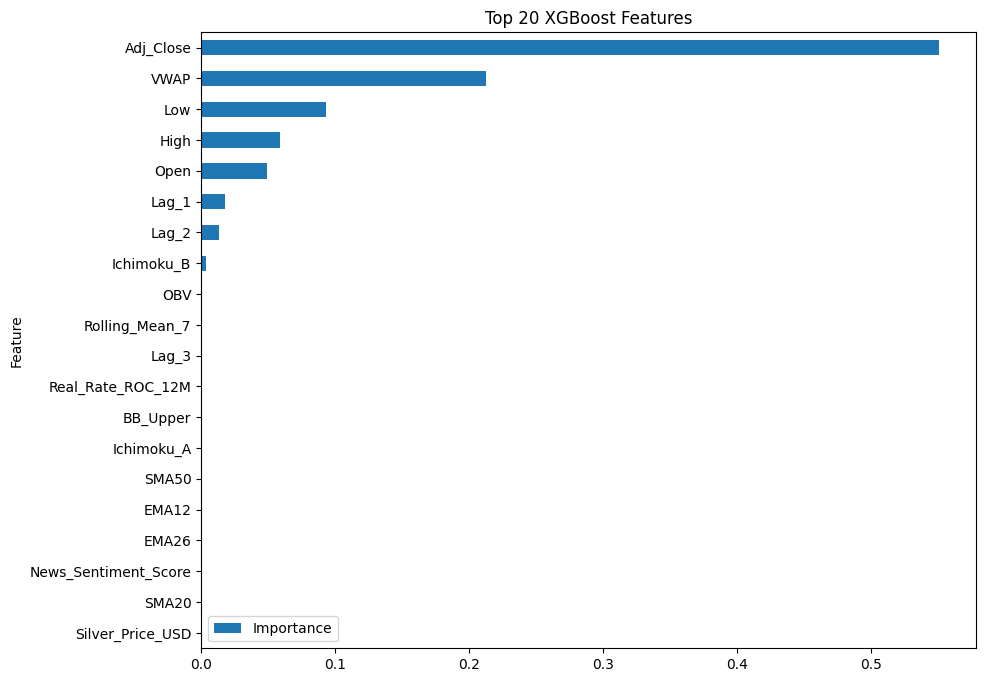

In [31]:
import matplotlib.pyplot as plt

importance.head(20).plot(

    x="Feature",

    y="Importance",

    kind="barh",

    figsize=(10,8)

)

plt.title(

    "Top 20 XGBoost Features"

)

plt.gca().invert_yaxis()

plt.show()

In [32]:
import joblib

joblib.dump(

    model,

    "xgboost_complete_model.pkl"

)

print("Model Saved")

Model Saved


In [33]:
print(

    "Total Features:",

    len(X_train.columns)

)

print(

    "Feature Importance Length:",

    len(model.feature_importances_)

)

Total Features: 109
Feature Importance Length: 109


In [34]:
print(X_train.dtypes[X_train.dtypes == "object"])

Series([], dtype: object)


In [35]:
print(X_train.shape)
print(X_train.dtypes.unique())

print("Object Columns:")
print(X_train.select_dtypes(include="object").columns.tolist())

print("Category Columns:")
print(X_train.select_dtypes(include="category").columns.tolist())

(5203, 109)
[dtype('float64') dtype('int64')]
Object Columns:
[]
Category Columns:
[]


In [36]:
print(type(X_train))

<class 'pandas.core.frame.DataFrame'>


In [37]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [38]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

mae_scores = []
rmse_scores = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):

    X_train_cv = X.iloc[train_idx]
    X_test_cv = X.iloc[test_idx]

    y_train_cv = y.iloc[train_idx]
    y_test_cv = y.iloc[test_idx]

    model_cv = XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        random_state=42
    )

    model_cv.fit(X_train_cv, y_train_cv)

    pred = model_cv.predict(X_test_cv)

    mae = mean_absolute_error(y_test_cv, pred)

    rmse = np.sqrt(np.mean((y_test_cv - pred) ** 2))

    mae_scores.append(mae)
    rmse_scores.append(rmse)

    print(f"Fold {fold+1}")
    print("MAE :", mae)
    print("RMSE:", rmse)
    print()

print("Average MAE :", np.mean(mae_scores))
print("Average RMSE:", np.mean(rmse_scores))

Fold 1
MAE : 4.375119782820135
RMSE: 5.445699025925069

Fold 2
MAE : 7.301489788125802
RMSE: 10.288729038198154

Fold 3
MAE : 0.08574725176117956
RMSE: 0.14670469488921986

Fold 4
MAE : 0.04273722665793787
RMSE: 0.07210701294491986

Fold 5
MAE : 0.08699527929664978
RMSE: 0.13640706108659012

Average MAE : 2.3784178657323407
Average RMSE: 3.2179293666087903


In [39]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(np.mean((y_test-rf_pred)**2))

print("Random Forest MAE :", rf_mae)
print("Random Forest RMSE:", rf_rmse)

Random Forest MAE : 0.022868639426546523
Random Forest RMSE: 0.03737027114962513


In [40]:
!pip install shap

In [41]:
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

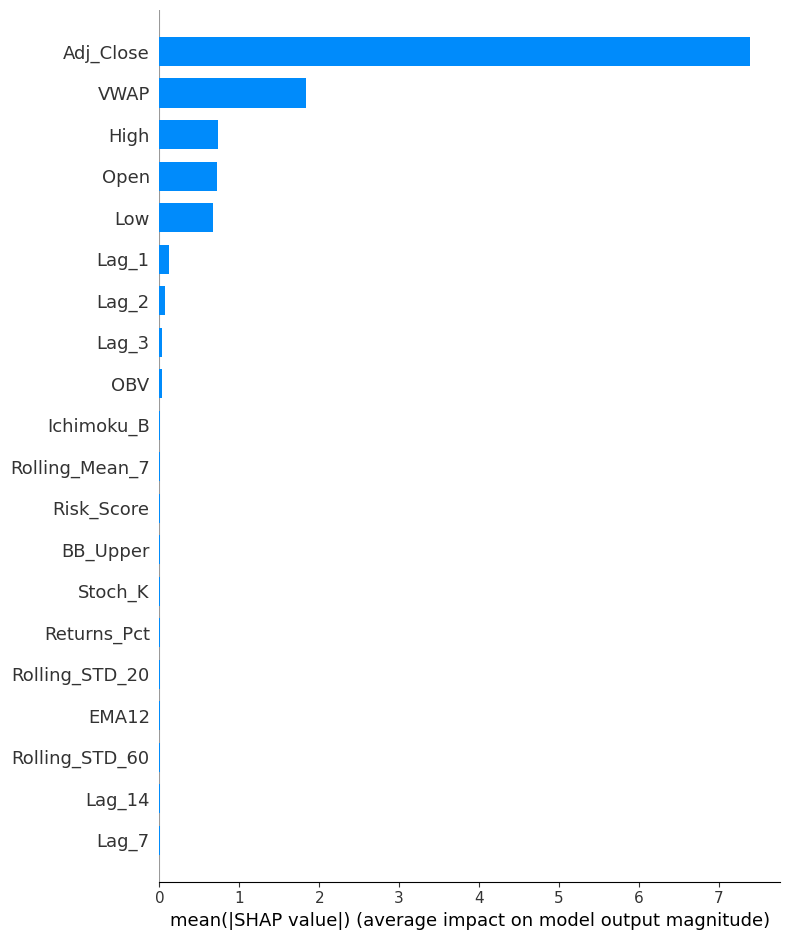

In [42]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

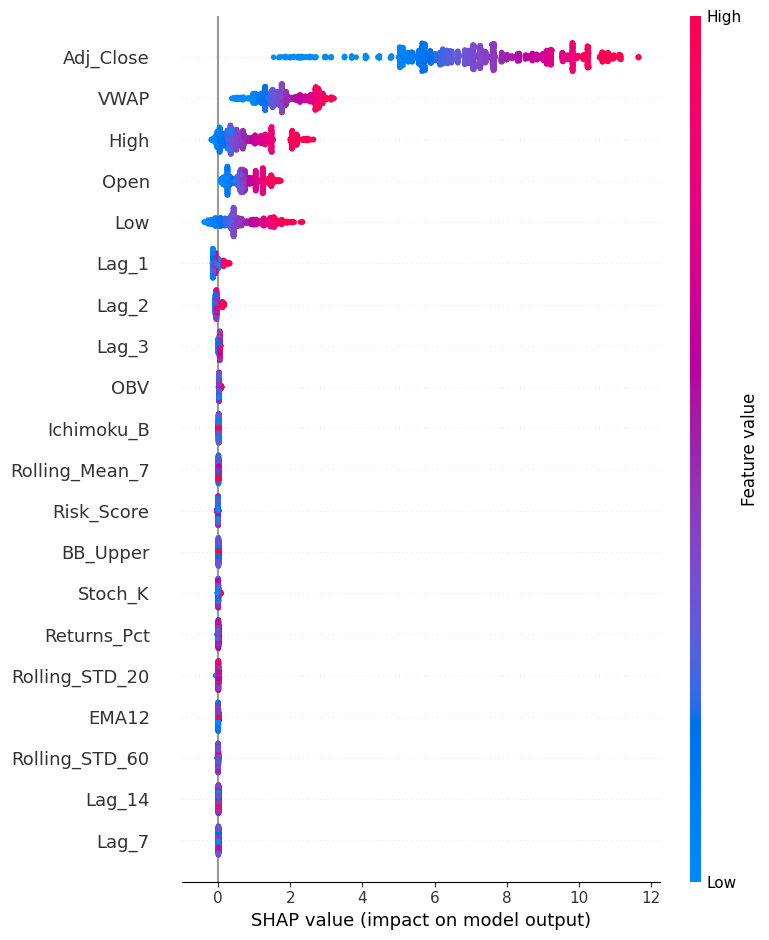

In [43]:
shap.summary_plot(
    shap_values,
    X_test
)

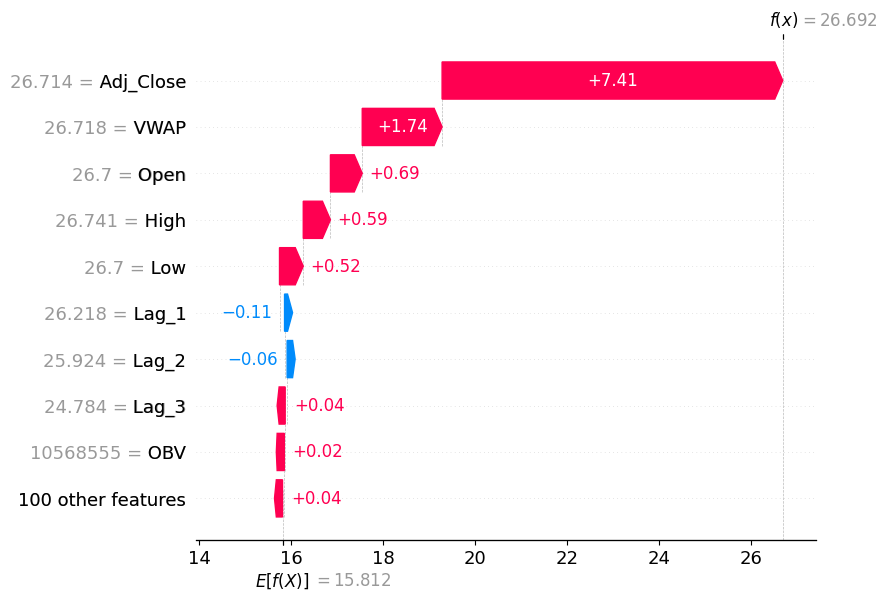

In [44]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)

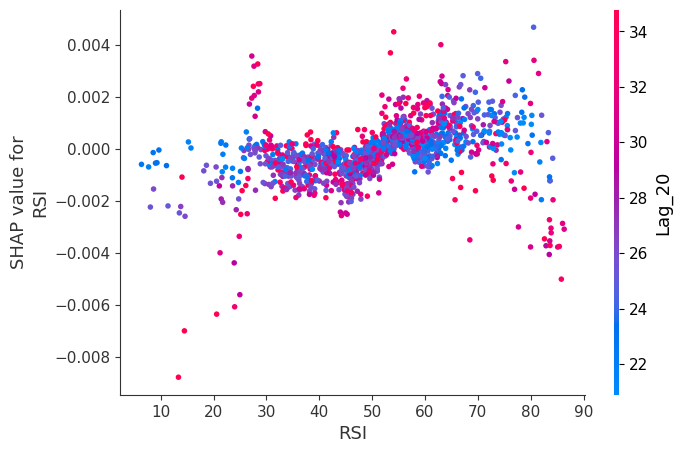

In [45]:
shap.dependence_plot(
    "RSI",
    shap_values,
    X_test
)

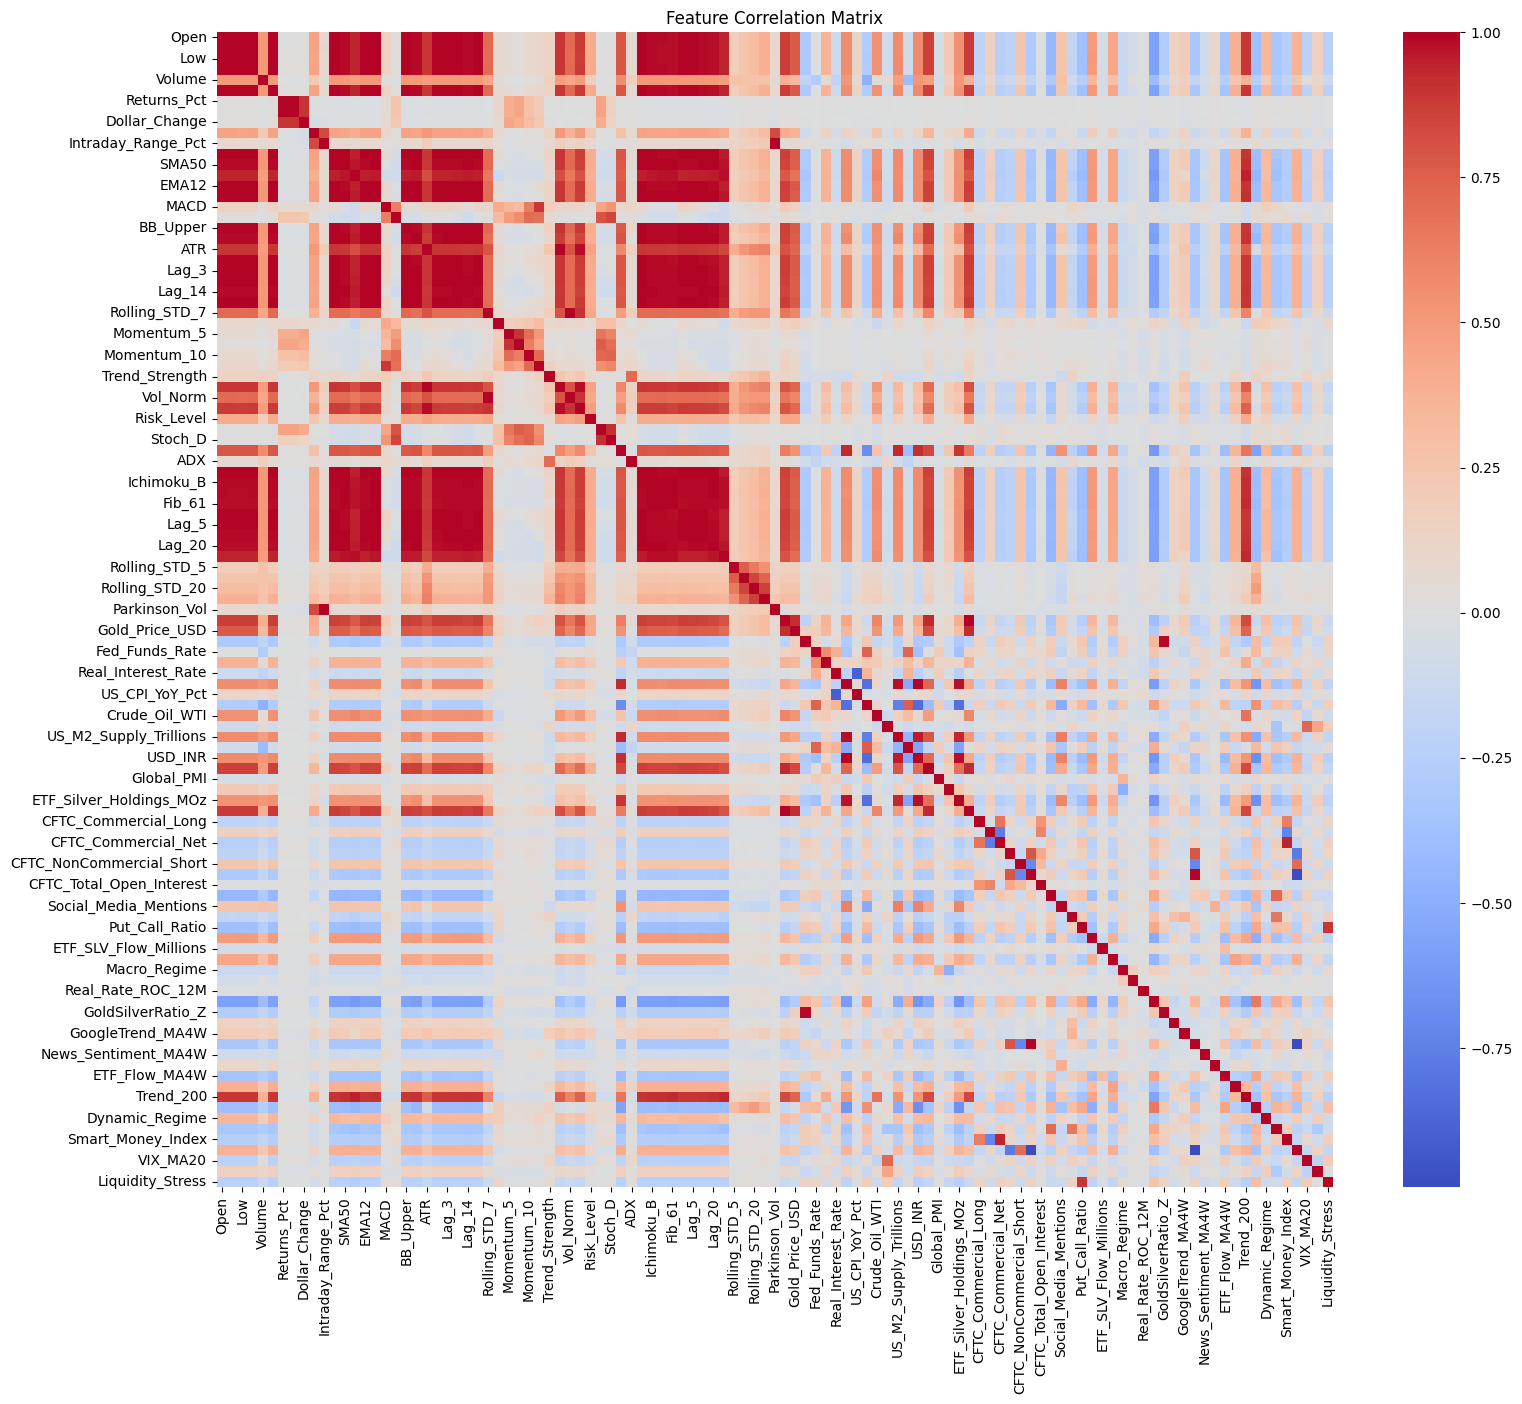

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = X.corr()

plt.figure(figsize=(18,15))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")

plt.show()

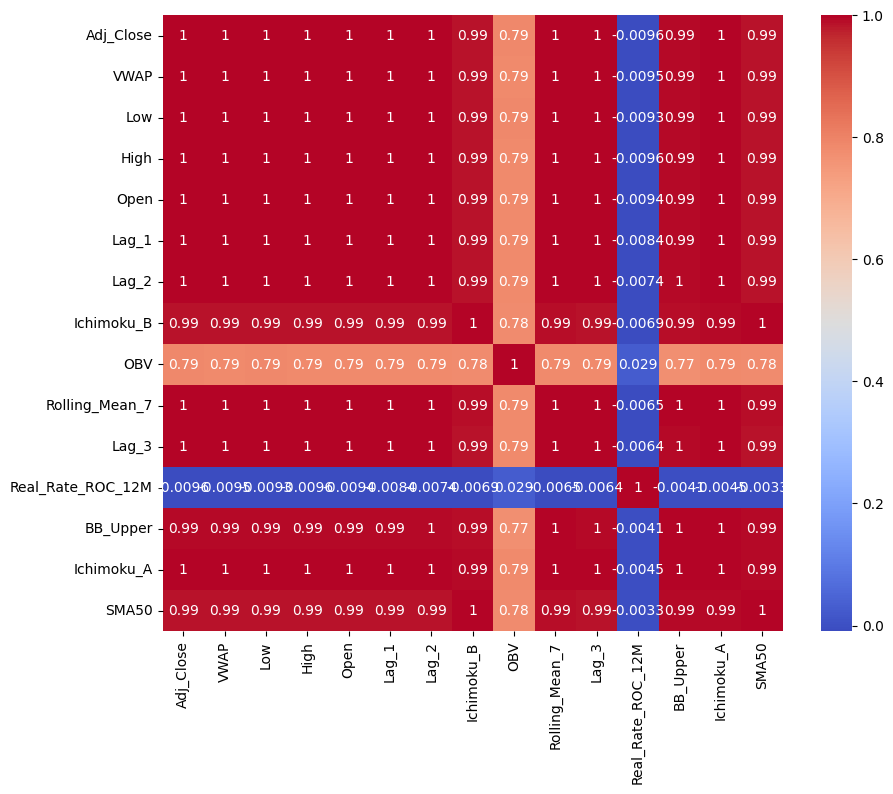

In [47]:
top_features = importance.head(15)["Feature"]

plt.figure(figsize=(10,8))

sns.heatmap(
    X[top_features].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

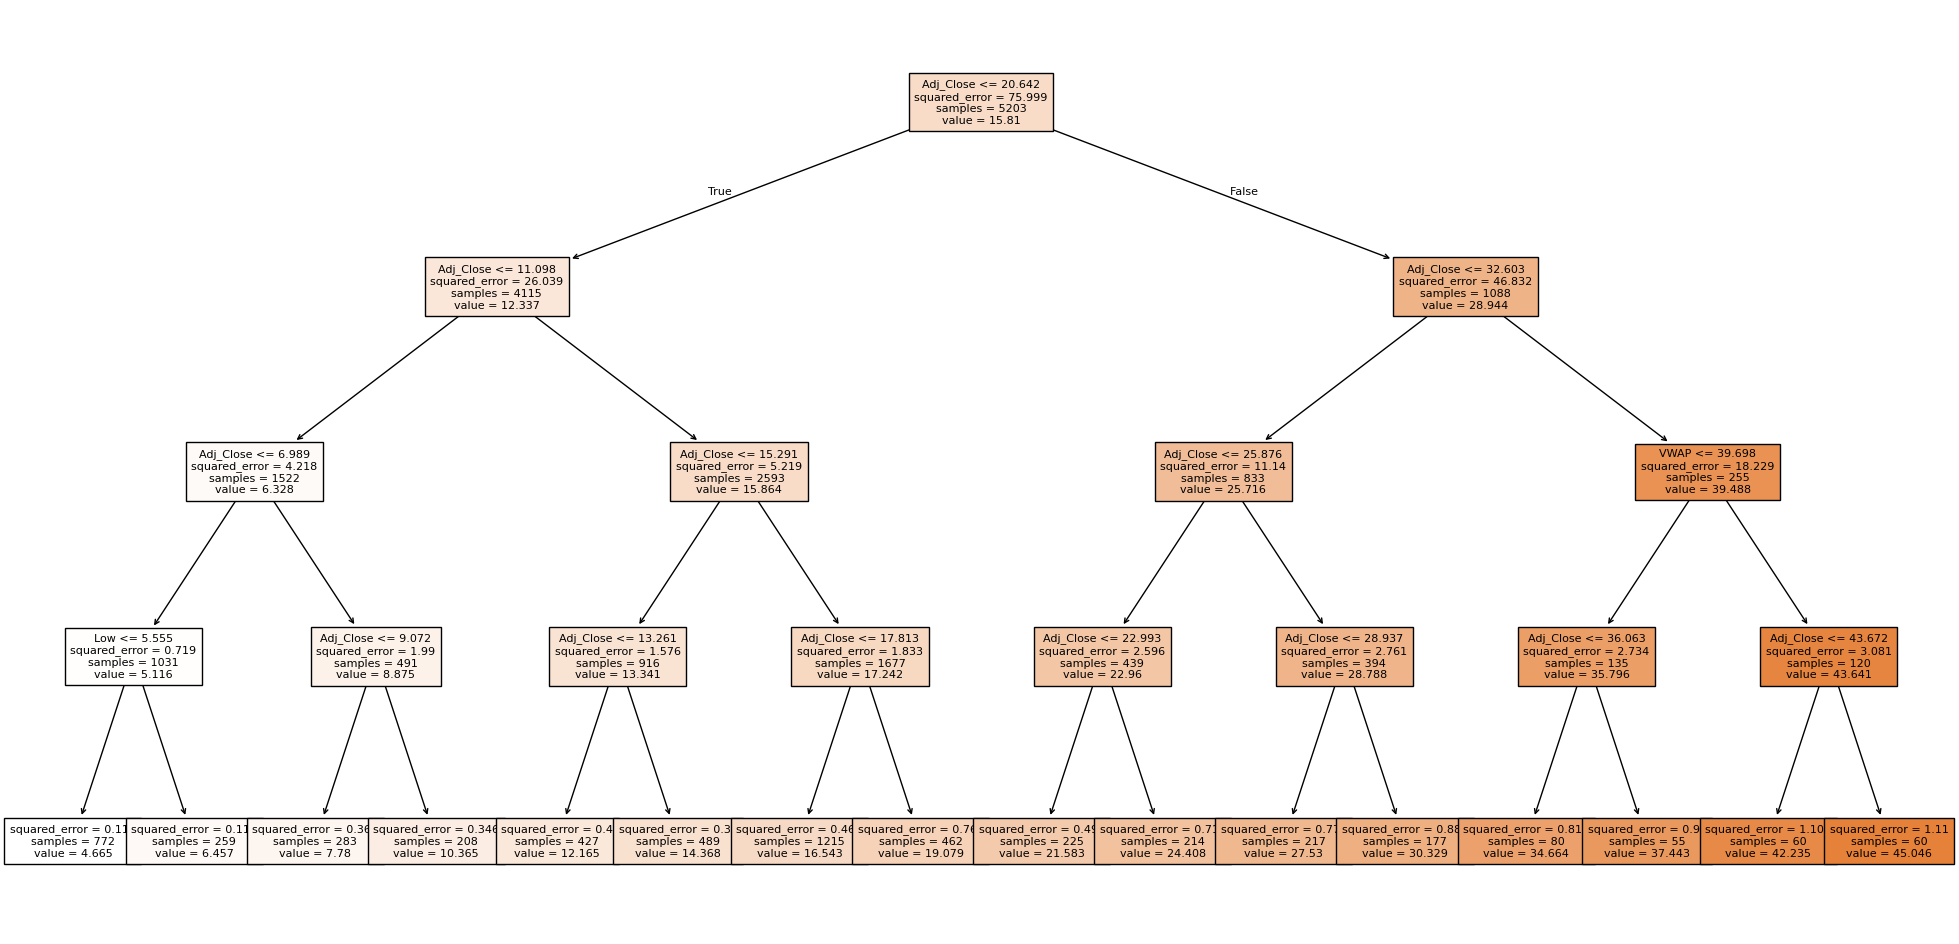

In [48]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree = DecisionTreeRegressor(
    max_depth=4,
    random_state=42
)

tree.fit(X_train,y_train)

plt.figure(figsize=(25,12))

plot_tree(
    tree,
    feature_names=X_train.columns,
    filled=True,
    fontsize=8
)

plt.show()

In [49]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.0 MB/s eta 0:00:00


In [50]:
import optuna
from sklearn.metrics import mean_squared_error

def objective(trial):

    params = {

        "n_estimators":
        trial.suggest_int("n_estimators",100,1000),

        "max_depth":
        trial.suggest_int("max_depth",3,10),

        "learning_rate":
        trial.suggest_float("learning_rate",0.01,0.3),

        "subsample":
        trial.suggest_float("subsample",0.5,1.0),

        "colsample_bytree":
        trial.suggest_float("colsample_bytree",0.5,1.0)

    }

    model = XGBRegressor(
        **params,
        random_state=42
    )

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    rmse = np.sqrt(
        mean_squared_error(y_test,pred)
    )

    return rmse

study = optuna.create_study(
    direction="minimize"
)

study.optimize(
    objective,
    n_trials=100
)

print("Best Parameters")

print(study.best_params)

print("Best RMSE")

print(study.best_value)

[I 2026-06-26 11:18:52,254] A new study created in memory with name: no-name-80c7b1be-966d-45da-9f69-fb9b35fd4902
[I 2026-06-26 11:20:08,155] Trial 0 finished with value: 0.1509550587304375 and parameters: {'n_estimators': 879, 'max_depth': 10, 'learning_rate': 0.01599520821861418, 'subsample': 0.7302707233797039, 'colsample_bytree': 0.770749918292684}. Best is trial 0 with value: 0.1509550587304375.
[I 2026-06-26 11:20:32,446] Trial 1 finished with value: 0.18144003912109735 and parameters: {'n_estimators': 507, 'max_depth': 7, 'learning_rate': 0.1678616343838393, 'subsample': 0.8039622132413828, 'colsample_bytree': 0.9006246360298917}. Best is trial 0 with value: 0.1509550587304375.
[I 2026-06-26 11:20:34,667] Trial 2 finished with value: 0.14847429594913958 and parameters: {'n_estimators': 483, 'max_depth': 3, 'learning_rate': 0.026352729163034862, 'subsample': 0.6221192468880823, 'colsample_bytree': 0.5856530672523291}. Best is trial 2 with value: 0.14847429594913958.
[I 2026-06-26

Best Parameters
{'n_estimators': 423, 'max_depth': 10, 'learning_rate': 0.024651216350111693, 'subsample': 0.7761656716408751, 'colsample_bytree': 0.8158505774186999}
Best RMSE
0.13785923158158578


In [51]:
import joblib

joblib.dump(
    model,
    "xgboost_final_optimized.pkl"
)

print("Optimized Model Saved")

Optimized Model Saved
